# Notebook 06 - Fusion Results Visualization

This notebook loads the final fusion result CSV files and creates simple visualizations.

Input files:

- `results/group_strategy_ranking.csv`
- `results/best_strategy_per_group.csv`
- `results/fold_results_summary.csv`

Output folder:

- `results/graphs/`

In [1]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [ ]:
# Locate repository folders
current_dir = Path.cwd()

if (current_dir / "results").exists():
    PROJECT_ROOT = current_dir
else:
    PROJECT_ROOT = current_dir.parent

RESULTS_DIR = PROJECT_ROOT / "results"
GRAPHS_DIR = RESULTS_DIR / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

GROUP_RANKING_PATH = RESULTS_DIR / "group_strategy_ranking.csv"
BEST_STRATEGY_PATH = RESULTS_DIR / "best_strategy_per_group.csv"
FOLD_RESULTS_PATH = RESULTS_DIR / "fold_results_summary.csv"

print("Project root:", PROJECT_ROOT)
print("Graphs directory:", GRAPHS_DIR)

In [3]:
# Load final fusion result tables
group_ranking = pd.read_csv(GROUP_RANKING_PATH)
best_strategy = pd.read_csv(BEST_STRATEGY_PATH)
fold_results = pd.read_csv(FOLD_RESULTS_PATH)

print("Group strategy ranking:", group_ranking.shape)
print("Best strategy per group:", best_strategy.shape)
print("Fold results:", fold_results.shape)

display(group_ranking.head())
display(best_strategy)

Group strategy ranking: (18, 16)
Best strategy per group: (6, 16)
Fold results: (180, 62)


,Group,Group Name,Strategy,Completed_Folds,RMSE_kcal_mean,RMSE_kcal_std,MAE_kcal_mean,R2_mean,RMSE_Wkg_mean,Val_RMSE_kcal_mean,BestEpoch_mean,Params_mean,Time_sec_mean,Best_Single_Signal,Best_Single_RMSE_kcal,Improvement_vs_Best_Single_%
0,G1,Local,intermediate_fusion,10,1.671406,0.466083,1.314167,0.582466,1.701741,1.251894,15.1,148545.0,386.845185,right Ankle Acceleration,2.052,18.547452
1,G1,Local,late_fusion,10,1.723374,0.456256,1.390603,0.589962,1.742714,1.343563,17.3,140561.0,431.991808,right Ankle Acceleration,2.052,16.014897
2,G1,Local,early_fusion,10,1.881433,0.660199,1.422471,0.542902,1.876615,1.449507,11.1,18465.0,56.936369,right Ankle Acceleration,2.052,8.312218
3,G2,Global,intermediate_fusion,10,1.099315,0.390444,0.802000,0.858204,1.096487,0.769585,11.2,148545.0,329.691146,Minute Ventilation,0.991,-10.929889
4,G2,Global,late_fusion,10,1.200099,0.505452,0.951580,0.808672,1.213738,0.748263,16.4,140561.0,399.309301,Minute Ventilation,0.991,-21.099791


,Group,Group Name,Strategy,Completed_Folds,RMSE_kcal_mean,RMSE_kcal_std,MAE_kcal_mean,R2_mean,RMSE_Wkg_mean,Val_RMSE_kcal_mean,BestEpoch_mean,Params_mean,Time_sec_mean,Best_Single_Signal,Best_Single_RMSE_kcal,Improvement_vs_Best_Single_%
0,G1,Local,intermediate_fusion,10,1.671406,0.466083,1.314167,0.582466,1.701741,1.251894,15.1,148545.0,386.845185,right Ankle Acceleration,2.052,18.547452
1,G2,Global,intermediate_fusion,10,1.099315,0.390444,0.802000,0.858204,1.096487,0.769585,11.2,148545.0,329.691146,Minute Ventilation,0.991,-10.929889
2,G3,Hexoskin,late_fusion,10,1.094248,0.428430,0.859157,0.856674,1.089510,0.695002,15.8,70281.0,198.503119,Minute Ventilation,0.991,-10.418532
3,G4,Physiological,late_fusion,10,1.067758,0.380149,0.859050,0.837631,1.092864,0.707837,16.7,70281.0,207.818279,Minute Ventilation,0.991,-7.745483
4,G5,Motion,intermediate_fusion,10,1.874649,0.677408,1.501402,0.590335,1.858291,1.380721,15.2,111425.0,255.463249,right Ankle Acceleration,2.052,8.642824
5,G6,Local + Global,intermediate_fusion,10,1.075271,0.317288,0.851974,0.865581,1.072010,0.703855,21.0,297025.0,937.379157,Minute Ventilation,0.991,-8.503666


In [10]:
# Create readable labels for plots
def strategy_label(strategy):
    labels = {
        "early_fusion": "Early",
        "intermediate_fusion": "Intermediate",
        "late_fusion": "Late",
    }
    return labels.get(strategy, strategy)


def group_label(row):
    return f"{row['Group']}\n{row['Group Name']}"


group_ranking["Strategy Label"] = group_ranking["Strategy"].apply(strategy_label)
group_ranking["Group Label"] = group_ranking.apply(group_label, axis=1)

best_strategy["Strategy Label"] = best_strategy["Strategy"].apply(strategy_label)
best_strategy["Group Label"] = best_strategy.apply(group_label, axis=1)

fold_results["Strategy Label"] = fold_results["Strategy"].apply(strategy_label)
fold_results["Group Label"] = fold_results.apply(group_label, axis=1)

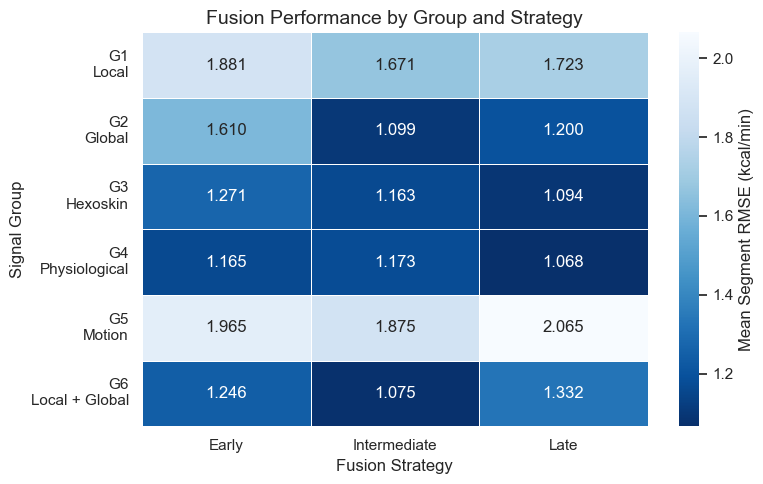

In [11]:
# Plot 1: Heatmap of all fusion strategies across groups
heatmap_data = group_ranking.pivot(
    index="Group Label",
    columns="Strategy Label",
    values="RMSE_kcal_mean",
)

strategy_order = ["Early", "Intermediate", "Late"]
heatmap_data = heatmap_data[strategy_order]

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="Blues_r",
    linewidths=0.5,
    cbar_kws={"label": "Mean Segment RMSE (kcal/min)"},
)
plt.title("Fusion Performance by Group and Strategy")
plt.xlabel("Fusion Strategy")
plt.ylabel("Signal Group")
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "fusion_rmse_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

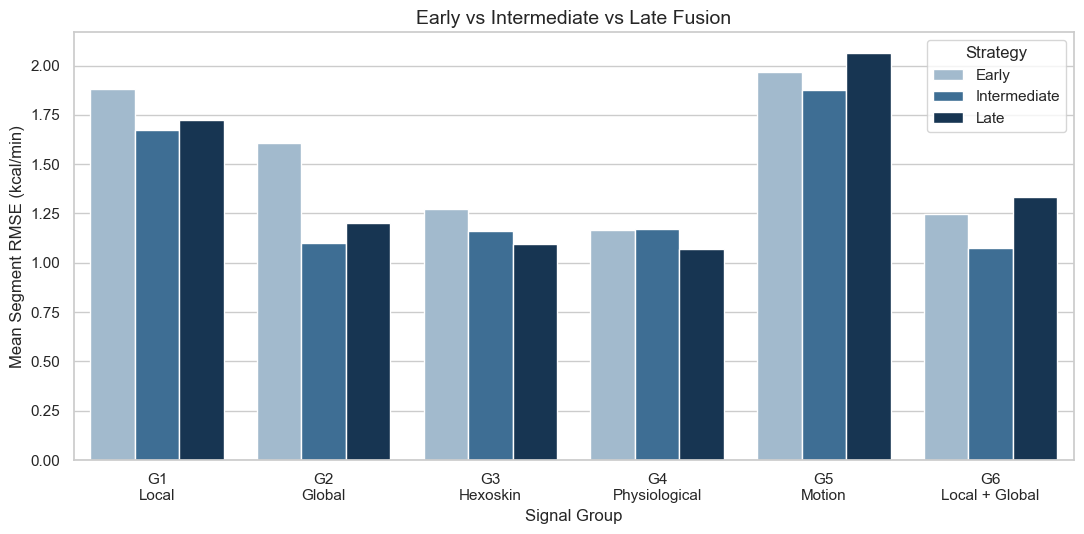

In [12]:
# Plot 2: Grouped bar chart for all fusion strategies
plt.figure(figsize=(11, 5.5))
sns.barplot(
    data=group_ranking,
    x="Group Label",
    y="RMSE_kcal_mean",
    hue="Strategy Label",
    hue_order=["Early", "Intermediate", "Late"],
    palette=["#9bbbd4", "#2f6fa3", "#0d355c"],
)
plt.title("Early vs Intermediate vs Late Fusion")
plt.xlabel("Signal Group")
plt.ylabel("Mean Segment RMSE (kcal/min)")
plt.legend(title="Strategy")
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "fusion_strategy_grouped_barplot.png", dpi=200, bbox_inches="tight")
plt.show()

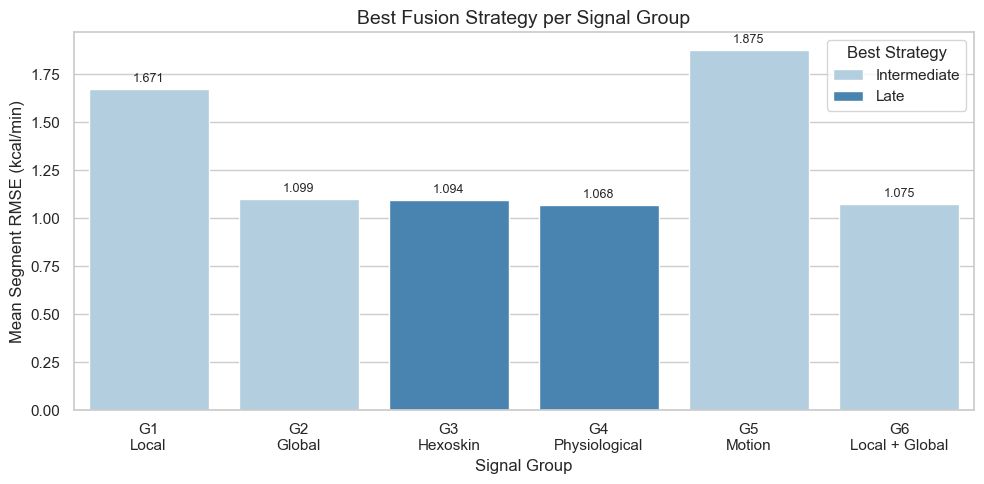

In [13]:
# Plot 3: Best fusion strategy per group
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=best_strategy,
    x="Group Label",
    y="RMSE_kcal_mean",
    hue="Strategy Label",
    dodge=False,
    palette="Blues",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Best Fusion Strategy per Signal Group")
plt.xlabel("Signal Group")
plt.ylabel("Mean Segment RMSE (kcal/min)")
plt.legend(title="Best Strategy")
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "fusion_best_strategy_per_group.png", dpi=200, bbox_inches="tight")
plt.show()

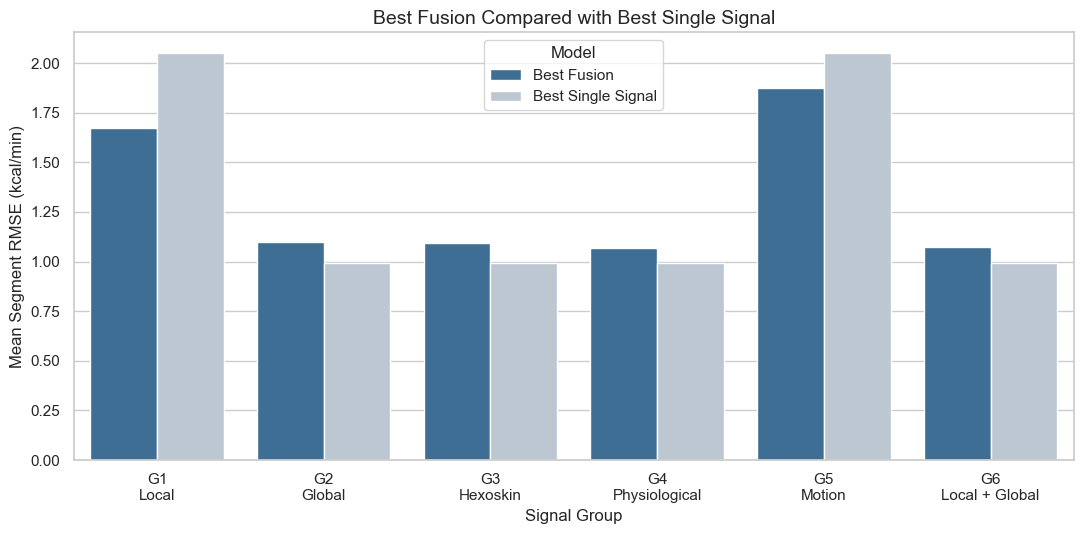

,Group,Group Name,Strategy Label,RMSE_kcal_mean,Best_Single_Signal,Best_Single_RMSE_kcal,Fusion minus Best Single
0,G1,Local,Intermediate,1.671406,right Ankle Acceleration,2.052,-0.380594
1,G2,Global,Intermediate,1.099315,Minute Ventilation,0.991,0.108315
2,G3,Hexoskin,Late,1.094248,Minute Ventilation,0.991,0.103248
3,G4,Physiological,Late,1.067758,Minute Ventilation,0.991,0.076758
4,G5,Motion,Intermediate,1.874649,right Ankle Acceleration,2.052,-0.177351
5,G6,Local + Global,Intermediate,1.075271,Minute Ventilation,0.991,0.084271


In [14]:
# Plot 4: Best fusion versus best single signal inside each group
comparison = best_strategy.copy()
comparison["Fusion minus Best Single"] = comparison["RMSE_kcal_mean"] - comparison["Best_Single_RMSE_kcal"]

comparison_long = pd.DataFrame()
comparison_long["Group Label"] = list(comparison["Group Label"]) + list(comparison["Group Label"])
comparison_long["Model"] = ["Best Fusion"] * len(comparison) + ["Best Single Signal"] * len(comparison)
comparison_long["RMSE_kcal"] = list(comparison["RMSE_kcal_mean"]) + list(comparison["Best_Single_RMSE_kcal"])

plt.figure(figsize=(11, 5.5))
sns.barplot(
    data=comparison_long,
    x="Group Label",
    y="RMSE_kcal",
    hue="Model",
    palette=["#2f6fa3", "#b9c7d5"],
)
plt.title("Best Fusion Compared with Best Single Signal")
plt.xlabel("Signal Group")
plt.ylabel("Mean Segment RMSE (kcal/min)")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "fusion_vs_best_single_signal.png", dpi=200, bbox_inches="tight")
plt.show()

display(comparison[[
    "Group",
    "Group Name",
    "Strategy Label",
    "RMSE_kcal_mean",
    "Best_Single_Signal",
    "Best_Single_RMSE_kcal",
    "Fusion minus Best Single",
]])

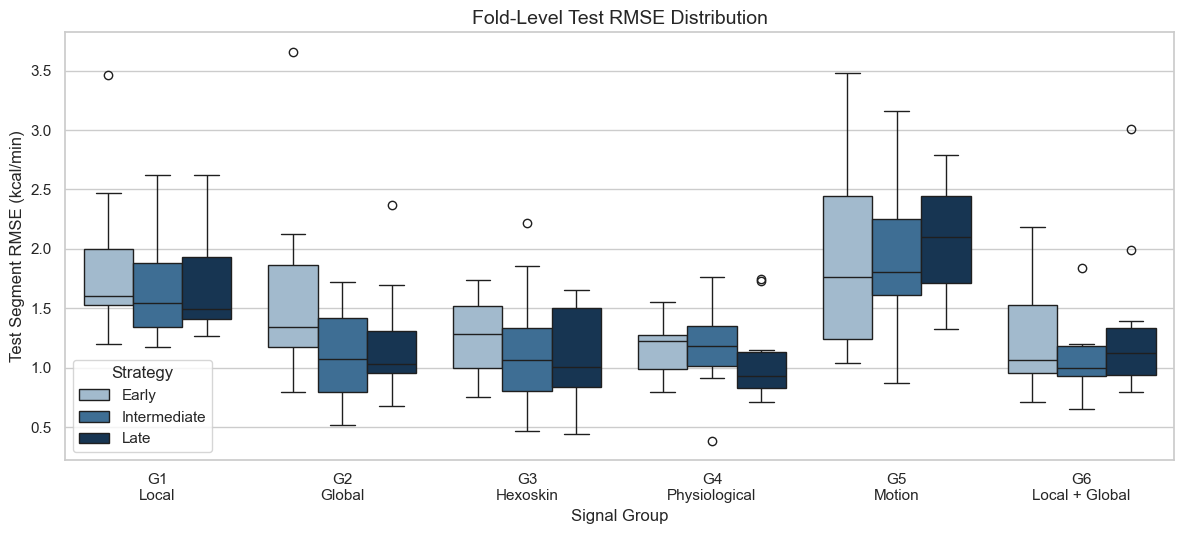

In [15]:
# Plot 5: Fold-level distribution of test RMSE
plt.figure(figsize=(12, 5.5))
sns.boxplot(
    data=fold_results,
    x="Group Label",
    y="Test_Segment_RMSE_kcal_min",
    hue="Strategy Label",
    hue_order=["Early", "Intermediate", "Late"],
    palette=["#9bbbd4", "#2f6fa3", "#0d355c"],
)
plt.title("Fold-Level Test RMSE Distribution")
plt.xlabel("Signal Group")
plt.ylabel("Test Segment RMSE (kcal/min)")
plt.legend(title="Strategy")
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "fusion_fold_rmse_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

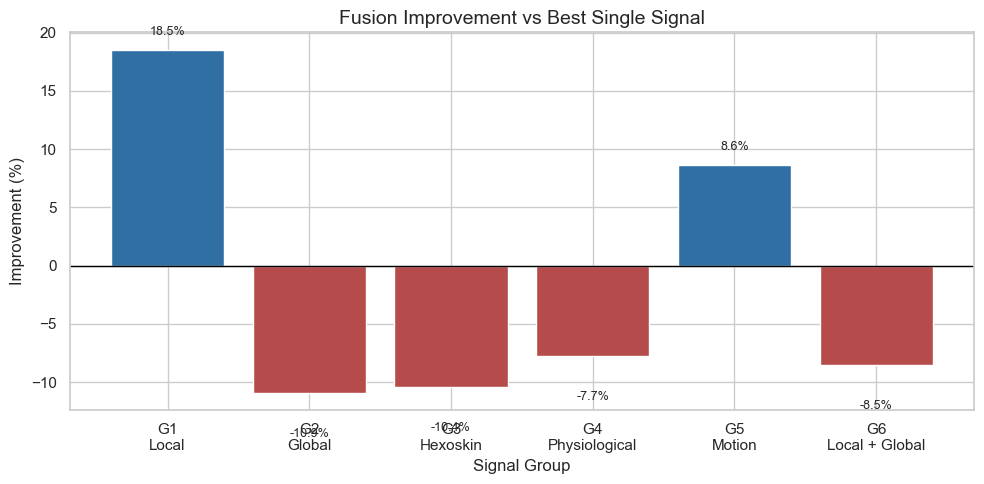

In [16]:
# Plot 6: Improvement relative to the best single signal
# Positive values mean fusion is better than the best single signal in that group.
comparison["Improvement Percent"] = comparison["Improvement_vs_Best_Single_%"]

colors = []
for value in comparison["Improvement Percent"]:
    if value >= 0:
        colors.append("#2f6fa3")
    else:
        colors.append("#b64b4b")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    comparison["Group Label"],
    comparison["Improvement Percent"],
    color=colors,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Fusion Improvement vs Best Single Signal")
plt.xlabel("Signal Group")
plt.ylabel("Improvement (%)")
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    label_y = height + 1 if height >= 0 else height - 3
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{height:.1f}%",
        ha="center",
        va="bottom" if height >= 0 else "top",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "fusion_improvement_vs_best_single.png", dpi=200, bbox_inches="tight")
plt.show()

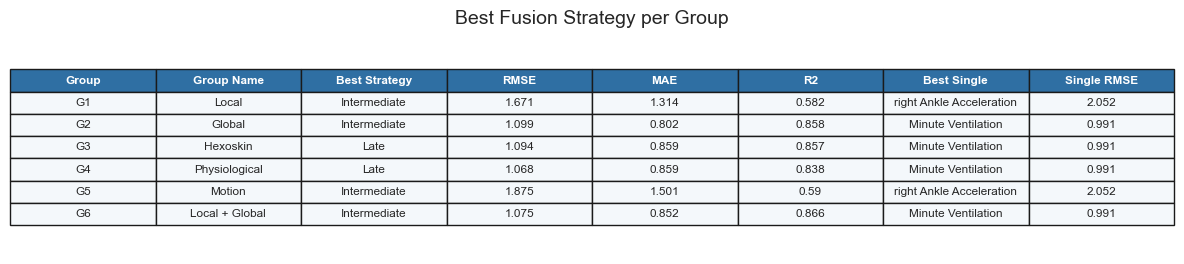

,Group,Group Name,Best Strategy,RMSE,MAE,R2,Best Single,Single RMSE
0,G1,Local,Intermediate,1.671,1.314,0.582,right Ankle Acceleration,2.052
1,G2,Global,Intermediate,1.099,0.802,0.858,Minute Ventilation,0.991
2,G3,Hexoskin,Late,1.094,0.859,0.857,Minute Ventilation,0.991
3,G4,Physiological,Late,1.068,0.859,0.838,Minute Ventilation,0.991
4,G5,Motion,Intermediate,1.875,1.501,0.590,right Ankle Acceleration,2.052
5,G6,Local + Global,Intermediate,1.075,0.852,0.866,Minute Ventilation,0.991


In [17]:
# Plot 7: Poster-friendly result table as image
summary_table = best_strategy[[
    "Group",
    "Group Name",
    "Strategy Label",
    "RMSE_kcal_mean",
    "MAE_kcal_mean",
    "R2_mean",
    "Best_Single_Signal",
    "Best_Single_RMSE_kcal",
]].copy()

summary_table = summary_table.rename(columns={
    "Strategy Label": "Best Strategy",
    "RMSE_kcal_mean": "RMSE",
    "MAE_kcal_mean": "MAE",
    "R2_mean": "R2",
    "Best_Single_Signal": "Best Single",
    "Best_Single_RMSE_kcal": "Single RMSE",
})

for column in ["RMSE", "MAE", "R2", "Single RMSE"]:
    summary_table[column] = summary_table[column].round(3)

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.35)

for key, cell in table.get_celld().items():
    row, col = key
    if row == 0:
        cell.set_facecolor("#2f6fa3")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#f4f8fb")

plt.title("Best Fusion Strategy per Group", pad=12)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "fusion_best_strategy_table.png", dpi=220, bbox_inches="tight")
plt.show()

display(summary_table)

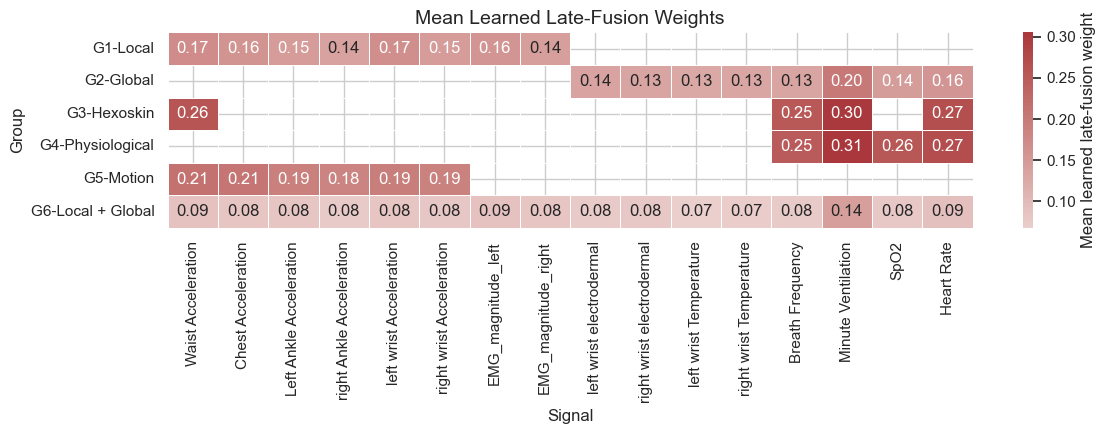

In [18]:
# Optional: late-fusion weights for interpretability
late_weight_columns = []
for column in fold_results.columns:
    if column.startswith("Late Weight - "):
        late_weight_columns.append(column)

late_rows = fold_results[fold_results["Strategy"] == "late_fusion"].copy()

if len(late_weight_columns) > 0 and not late_rows.empty:
    weight_summary = late_rows.groupby(["Group", "Group Name"])[late_weight_columns].mean()
    weight_summary.columns = [column.replace("Late Weight - ", "") for column in weight_summary.columns]
    weight_summary = weight_summary.dropna(axis=1, how="all")

    plt.figure(figsize=(12, 4.5))
    sns.heatmap(
        weight_summary,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Mean learned late-fusion weight"},
    )
    plt.title("Mean Learned Late-Fusion Weights")
    plt.xlabel("Signal")
    plt.ylabel("Group")
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / "fusion_late_weights_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No late-fusion weight columns found.")

In [19]:
# Print all generated graph files
created_files = sorted(GRAPHS_DIR.glob("fusion_*.png"))
for file_path in created_files:
    print(file_path.name)

fusion_best_strategy_per_group.png
fusion_best_strategy_table.png
fusion_fold_rmse_boxplot.png
fusion_improvement_vs_best_single.png
fusion_late_weights_heatmap.png
fusion_rmse_heatmap.png
fusion_strategy_grouped_barplot.png
fusion_vs_best_single_signal.png
